In [1]:
#step 1:importing lib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\GANAPATI\Downloads\archive (8)\spam.csv", encoding='latin-1')[['v1','v2']]
df.columns = ['Label', 'Message']

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df['Label'] = (df['Label'] == 'spam').astype(int)
df['Label'].value_counts()


Label
0    4825
1     747
Name: count, dtype: int64

In [11]:
X = df['Message']
y = df['Label']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


Train samples: 4457
Test samples: 1115


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,
    max_features=5000
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


In [14]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_vec, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
from sklearn.metrics import accuracy_score, classification_report

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.9757847533632287
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



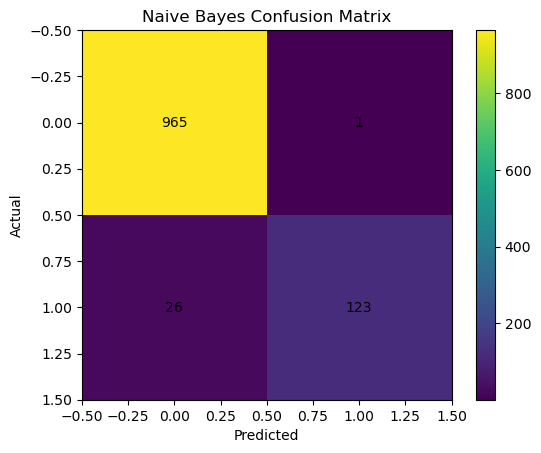

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

plt.imshow(cm)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [17]:
msg = ["Congratulations! You have won a free prize"]
msg_vec = tfidf.transform(msg)

print("Prediction:", "Spam" if nb_model.predict(msg_vec)[0] == 1 else "Ham")


Prediction: Spam
